In [1]:
# ── Notebook parameters ─────────────────────────────────────────
# Defaults for interactive use. extract_notebook_figures.py will
# override these via a cell injected right below this one.
#
# Add notebook-level globals here, e.g.:
# Analyzes an INR FPCA checkpoint. Produce one first with
#   python fpca.py +fpca_experiment=dwsnets_mnist_eulerian    (EXP_NAME='MNIST')
#   python fpca.py +fpca_experiment=implicit_zoo_cifar_eulerian  (EXP_NAME='CIFAR10')
# The run directory name is not predictable: `wandb-<run id>` with wandb enabled,
# otherwise a timestamp. List outputs/checkpoints/, pick your run, and use the
# highest step_*.pt (or best.pt) inside it.
CHECKPOINT_DIR  = "../outputs/checkpoints/XXX"
CHECKPOINT_FILE = "step_XXX.pt"
EXP_NAME = "MNIST"

# Visualization and reconstruction
CMAP = "Greys_r"
N_MEAN = 64
N_BATCH_SHOW = 12
N_VIS_ATOMS = 32
BASIS_VIS_ATOMS = 81
N_VAL = 4
N_RECON = 32
N_SHOW_LINEAR = 12
ATOM_TILE_SIZE = 0.55
RECON_ATOM_BUDGETS = [1, 4, 16, 64, 128, 256]
MOSAIC_THRESHOLD = 3

# Spectral diagnostics
N_SPEC = 200
SPECTRAL_ATOMS = 256
N_VIS_SPEC = 32
N_VIOLIN = 10


## 1  FPCA Checkpoint — Setup

Load a checkpoint produced by `fpca.py` with either the
`dwsnets_mnist_eulerian` or `implicit_zoo_cifar_eulerian` experiment config.
All architecture and data-path details are read from the saved `config.yaml`.

In [2]:
%matplotlib inline
import sys
sys.path.insert(0, "..")

In [3]:

# ──────────────────────────────────────────────────────────────────────────────

import yaml
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from omegaconf import OmegaConf
from hydra.utils import instantiate

from infidictionary.datasets.inr import _eval_siren_batch
from infidictionary.neural_isometries import NeuralIsometry
from infidictionary.networks import NeuralField
from infidictionary.dictionaries import InfiDictionary
from infidictionary.domain_samplers import SquareSampler
from infidictionary.utils import pairwise_inner_product
from notebook_helpers import (
    plot_atom_mosaic, plot_atoms_comparison, show_field, visualize_generator_U,
    psnr_matrix, plot_psnr_line_chart, plot_spectral_compactness,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

with open(f"{CHECKPOINT_DIR}/config.yaml") as f:
    conf = OmegaConf.create(yaml.safe_load(f))

# Config paths are relative to the repository root, not the notebook kernel cwd.
_repo_root = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents)
     if (candidate / "infidictionary").is_dir()),
    None,
)
if _repo_root is None:
    raise RuntimeError("Could not locate the repository root from the notebook working directory")
if OmegaConf.select(conf, "ood_function_generator") is None:
    raise ValueError(
        "This checkpoint predates the explicit `ood_function_generator` config. "
        "Retrain it with the current INR FPCA experiment configuration."
    )

def resolve_dataset_paths(dataset_cfg):
    for path_key in ("data_dir", "extracted_dir"):
        value = dataset_cfg.get(path_key)
        if value is not None:
            path = Path(str(value))
            dataset_cfg[path_key] = str(path if path.is_absolute() else _repo_root / path)

resolve_dataset_paths(conf.function_generator)
resolve_dataset_paths(conf.ood_function_generator)

# ── Optionally cap the number of loaded INRs to speed things up ───────────────
# OmegaConf.update(conf, "function_generator.n_inrs", 500, merge=True)

neural_isometry: NeuralIsometry    = instantiate(conf.neural_isometry).to(device)
mean_function:   NeuralField       = instantiate(conf.mean_function).to(device)
initial_dictionary: InfiDictionary = instantiate(conf.initial_dictionary).to(device)
function_generator                 = instantiate(conf.function_generator)

ckpt = torch.load(
    f"{CHECKPOINT_DIR}/{CHECKPOINT_FILE}", map_location=device, weights_only=False
)
neural_isometry.load_state_dict(ckpt["models"]["neural_isometry"])
mean_function.load_state_dict(ckpt["models"]["mean_function"])
if "initial_dictionary" in ckpt["models"]:
    initial_dictionary.load_state_dict(ckpt["models"]["initial_dictionary"])

model_state_kwargs = OmegaConf.to_container(
    conf.get("model_state_kwargs", {"num_steps": 200}), resolve=True
)
pullback_kwargs = OmegaConf.to_container(
    conf.get("pullback_pushforward_kwargs", {}), resolve=True
)

neural_isometry.shuffle_model_state(**model_state_kwargs)
neural_isometry.eval()
mean_function.eval()

CHANNELS_DIM = int(conf.initial_dictionary.get("num_channels", 1))
dictionary_name = type(initial_dictionary).__name__.removesuffix("Dictionary")
raw_basis_label = f"Raw {dictionary_name}"
transported_basis_label = "Learned Dictionary"

print(f"Loaded  : {CHECKPOINT_DIR}/{CHECKPOINT_FILE}  epoch={ckpt['epoch']}")
print(f"Metric  : {ckpt.get('metric', float('nan')):.4f}  |  best: {ckpt.get('best_metric', float('nan')):.4f}")
print(f"Dataset : {type(function_generator).__name__}  n_inrs={function_generator.n_inrs}  C={CHANNELS_DIM}")

from infidictionary.neural_isometries import IdentityIsometry
from notebook_helpers import plot_recon_grid

def top_probability_indices(dictionary: InfiDictionary, count: int) -> tuple[torch.Tensor, torch.Tensor]:
    """Return up to ``count`` distinct atoms in descending PMF order."""
    if count <= 0:
        raise ValueError(f"count must be positive; got {count}")
    if not getattr(dictionary, "is_infinite", False):
        candidates = dictionary.get_high_probability_indices(0.0)
        pmfs = dictionary.get_index_pmfs(candidates)
        order = pmfs.argsort(descending=True)[:count]
        return candidates[order], pmfs[order]
    threshold = 1.0
    for _ in range(128):
        candidates = dictionary.get_high_probability_indices(threshold)
        if candidates.shape[0] >= count:
            pmfs = dictionary.get_index_pmfs(candidates)
            order = pmfs.argsort(descending=True)[:count]
            return candidates[order], pmfs[order]
        threshold *= 0.5
    raise RuntimeError(f"Could not find {count} high-probability dictionary atoms")

def reconstruct_with_isometry(
    coords: torch.Tensor, functions: torch.Tensor, neural_isometry: NeuralIsometry,
    mean_function: NeuralField, dictionary: InfiDictionary, atom_indices: torch.Tensor,
    synthesis: bool = True,
    **transform_kwargs,
) -> torch.Tensor:
    """Project onto selected synthesized atoms in pullback coordinates, then map back."""
    mean = mean_function(coords)
    src_coords, src_lad, pulled = neural_isometry.pullback(
        tgt_coords=coords, tgt_logabsdet=torch.zeros(coords.shape[0], device=coords.device),
        tgt_field=functions - mean.unsqueeze(0), **transform_kwargs,
    )
    atoms = dictionary.get_atoms(src_coords, atom_indices.to(src_coords.device), synthesis=synthesis)
    coefficients = pairwise_inner_product(pulled, atoms, src_lad)
    projected = (coefficients @ atoms.reshape(atoms.shape[0], -1)).view_as(pulled)
    _, _, reconstruction = neural_isometry.pushforward(src_coords, src_lad, projected, **transform_kwargs)
    return reconstruction + mean.unsqueeze(0)

def eval_inrs_at_coords(fg, coords_01, num_elements, seed, dev):
    """Randomly sample num_elements SIRENs and evaluate at coords in [0,1]² → (num_elements, N, C)."""
    n_total = fg.weights[0].shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.choice(n_total, size=min(num_elements, n_total), replace=False)
    sc = torch.stack([
        2.0 * coords_01[:, 0] - 1.0,
        1.0 - 2.0 * coords_01[:, 1],
    ], dim=-1).to(dev)
    w  = [W[idx].to(dev) for W in fg.weights]
    b  = [bb[idx].to(dev) for bb in fg.biases]
    from infidictionary.datasets.inr import _eval_siren_batch
    with torch.no_grad():
        return _eval_siren_batch(sc, w, b, fg.omega_0, fg.omega)

Device: cuda
Loaded  : ../outputs/checkpoints/wandb-XXX/step_XXX.pt  epoch=999
Metric  : 0.0039  |  best: 0.0041
Dataset : ImplicitZooMNISTDataset  n_inrs=1024  C=1


## 2  Sample Batch Gallery

A quick look at what the loaded `function_generator` actually contains.
MNIST uses hexbin (C=1, grayscale); CIFAR-10 uses RGB scatter (C=3).

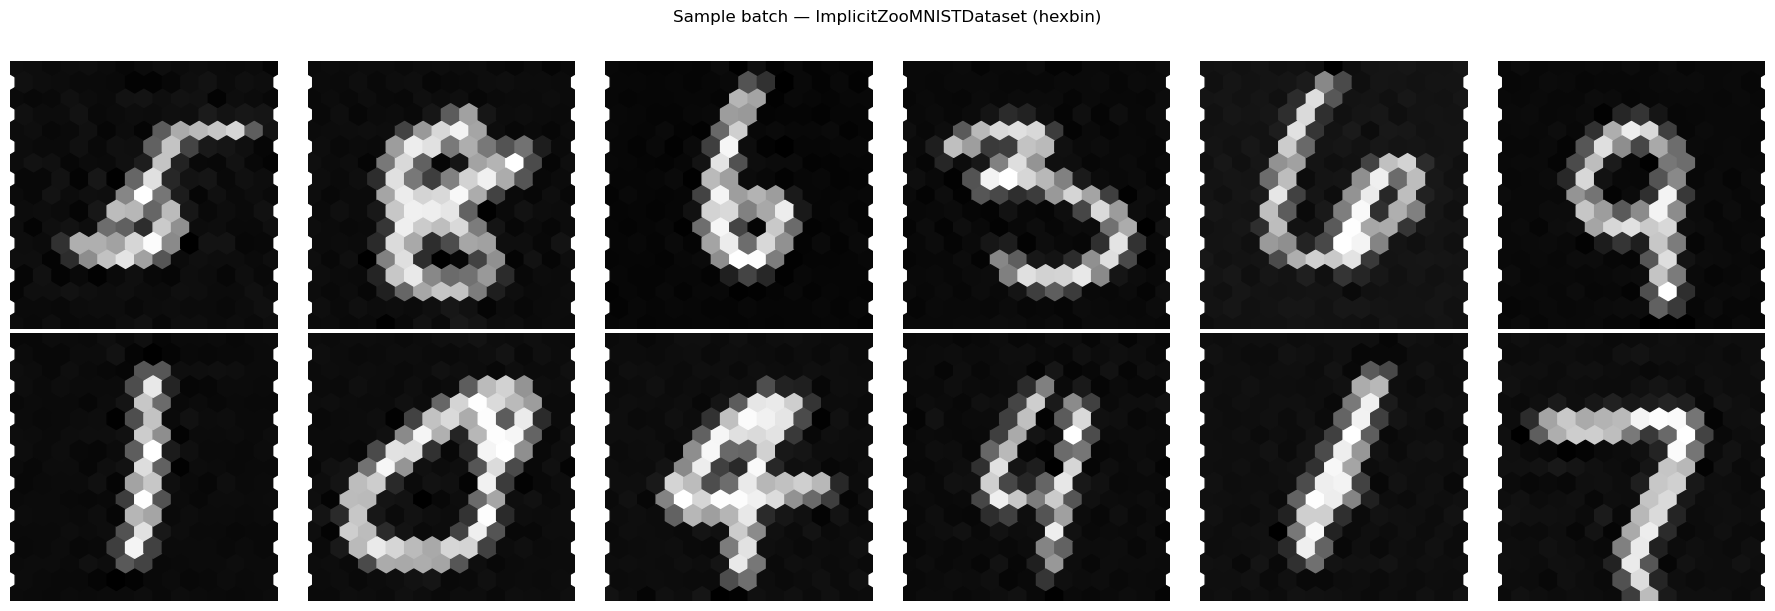

In [4]:
function_generator.reset_buffer()
c_b, v_b = function_generator.get_batch(N_BATCH_SHOW)   # coords in [0,1]²
xy_b = c_b.detach().cpu().numpy()                  # display in [0,1]²

fig, axes = plt.subplots(2, N_BATCH_SHOW // 2, figsize=(18, 6))

if CHANNELS_DIM == 1:
    for i, ax in enumerate(axes.flat):
        vals_i = v_b[i, :, 0].detach().cpu().numpy()
        ax.hexbin(xy_b[:, 0], xy_b[:, 1], C=vals_i,
                  gridsize=14, cmap='gray', reduce_C_function=np.mean)
        ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
        ax.set_aspect('equal'); ax.axis('off')
    plt.suptitle(f'Sample batch — {type(function_generator).__name__} (hexbin)', y=1.01)
else:
    for i, ax in enumerate(axes.flat):
        rgb = v_b[i].detach().cpu().numpy()   # (N, 3)
        rgb_norm = (rgb - rgb.min(0)) / (rgb.max(0) - rgb.min(0) + 1e-8)
        ax.scatter(xy_b[:, 0], xy_b[:, 1], c=rgb_norm, s=50, alpha=0.7)
        ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
        ax.set_aspect('equal'); ax.axis('off')
    plt.suptitle(f'Sample batch — {type(function_generator).__name__} (RGB scatter)', y=1.01)

plt.tight_layout()
plt.show()

### Learned Mean Function $\mu(x)$

Co-trained with the isometry; Minimizes MSE to the dataset mean.
The isometry then diagonalises the covariance of the *zero-centred* data.

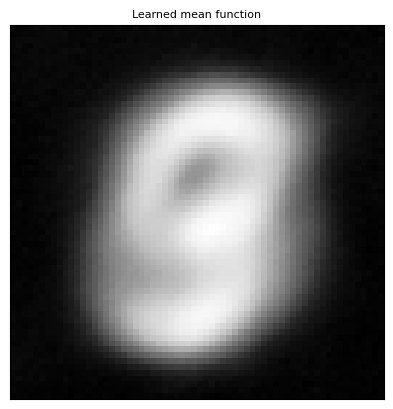

In [5]:
coords_mean = SquareSampler(stratified=True, add_noise=False).sample(N_MEAN).to(device)
with torch.no_grad():
    mean_vals = mean_function(coords_mean)   # (N, C)

fig, ax = plt.subplots(figsize=(4.2, 4.2))
show_field(ax, mean_vals, N_MEAN, title="Learned mean function", cmap=CMAP)
plt.tight_layout(); plt.show()

## 3  Learned Basis — Initial Atoms vs. Pushed-Forward Atoms

Select the highest-PMF atoms from the configured initial dictionary and evaluate
their learned pushforwards on a regular grid.
Grayscale for MNIST ($C=1$); separate R/G/B panels for CIFAR ($C=3$).

The atom mosaic is the primary visual diagnostic: if the isometry has
converged, the pushed-forward atoms should look like data-adapted basis
functions (e.g. edges, blobs, colour patches) rather than the initial atoms.

Showing 81 top-PMF atoms from Fourier (C=1)


/home/hamid/projects/learning-projections/notebooks/notebook_helpers.py:397: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


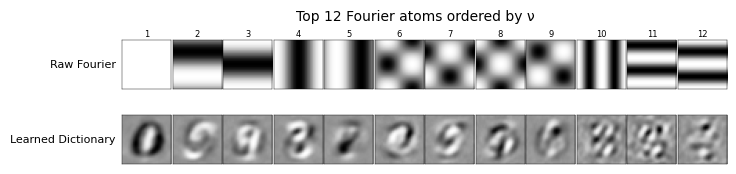

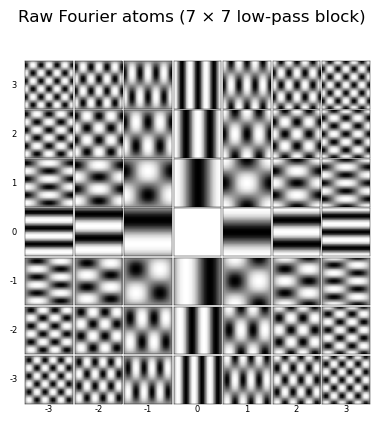

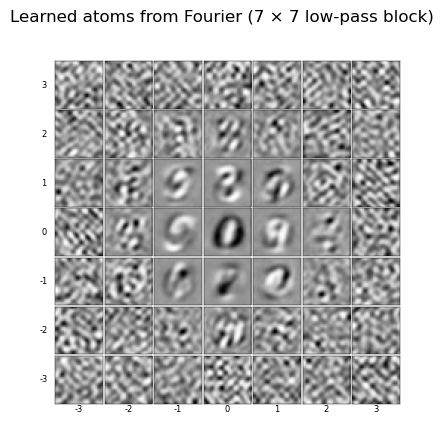

In [6]:
coords_atoms = SquareSampler(stratified=True, add_noise=False).sample(N_VIS_ATOMS).to(device)
lad_atoms    = torch.zeros(coords_atoms.shape[0], device=device)

# Dictionary-neutral PMF ordering; finite dictionaries are capped automatically.
indices_nu, nu_all = top_probability_indices(initial_dictionary, BASIS_VIS_ATOMS)
print(f"Showing {indices_nu.shape[0]} top-PMF atoms from {dictionary_name} (C={CHANNELS_DIM})")

neural_isometry.shuffle_model_state(**model_state_kwargs)
with torch.no_grad():
    # Display raw initial atoms; transport starts from the trained synthesis basis.
    atoms_src = initial_dictionary.get_atoms(coords_atoms, indices_nu, synthesis=False)
    atoms_for_transport = initial_dictionary.get_atoms(coords_atoms, indices_nu, synthesis=True)
    _, _, atoms_tgt = neural_isometry.pushforward(
        coords_atoms, lad_atoms, atoms_for_transport, **pullback_kwargs,
    )                                                                         # (A, N, C)

# ── 2-row linear comparison (ν-ordered) ──────────────────────────────────────
plot_atoms_comparison(
    atoms_src.cpu(), atoms_tgt.cpu(),
    n_vis=N_VIS_ATOMS, n_show=N_SHOW_LINEAR, tile_size=ATOM_TILE_SIZE, cmap=CMAP,
    row_labels=(raw_basis_label, transported_basis_label),
    title=f"Top {N_SHOW_LINEAR} {dictionary_name} atoms ordered by ν",
)

# Use a complete central 7 × 7 Fourier grid rather than a partial PMF shell.
if indices_nu.shape[1] == 3 and getattr(initial_dictionary, "domain_dim", None) == 2:
    mosaic_mask = indices_nu[:, :2].abs().amax(dim=1) <= MOSAIC_THRESHOLD
    plot_atom_mosaic(atoms_src[mosaic_mask].cpu(), indices_nu[mosaic_mask].cpu(),
                     title=f"Raw {dictionary_name} atoms ({MOSAIC_THRESHOLD * 2 + 1} × {MOSAIC_THRESHOLD * 2 + 1} low-pass block)",
                     n_vis=N_VIS_ATOMS, tile_size=ATOM_TILE_SIZE, cmap=CMAP)
    plot_atom_mosaic(atoms_tgt[mosaic_mask].cpu(), indices_nu[mosaic_mask].cpu(),
                     title=f"Learned atoms from {dictionary_name} ({MOSAIC_THRESHOLD * 2 + 1} × {MOSAIC_THRESHOLD * 2 + 1} low-pass block)",
                     n_vis=N_VIS_ATOMS, tile_size=ATOM_TILE_SIZE, cmap=CMAP)
else:
    print("Skipping Fourier-style (k₁, k₂) mosaic for this dictionary index layout.")


## 4  Reconstruction — In-Distribution

Reconstruction in the configured initial dictionary vs. its learned transported basis, at several PMF-ranked atom budgets. PSNR (dB) is shown above each tile.

In-distribution signals: (4, 1024, 1)


Reconstruction atom budgets: [1, 4, 16, 64, 128, 256]


/home/hamid/projects/learning-projections/notebooks/notebook_helpers.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


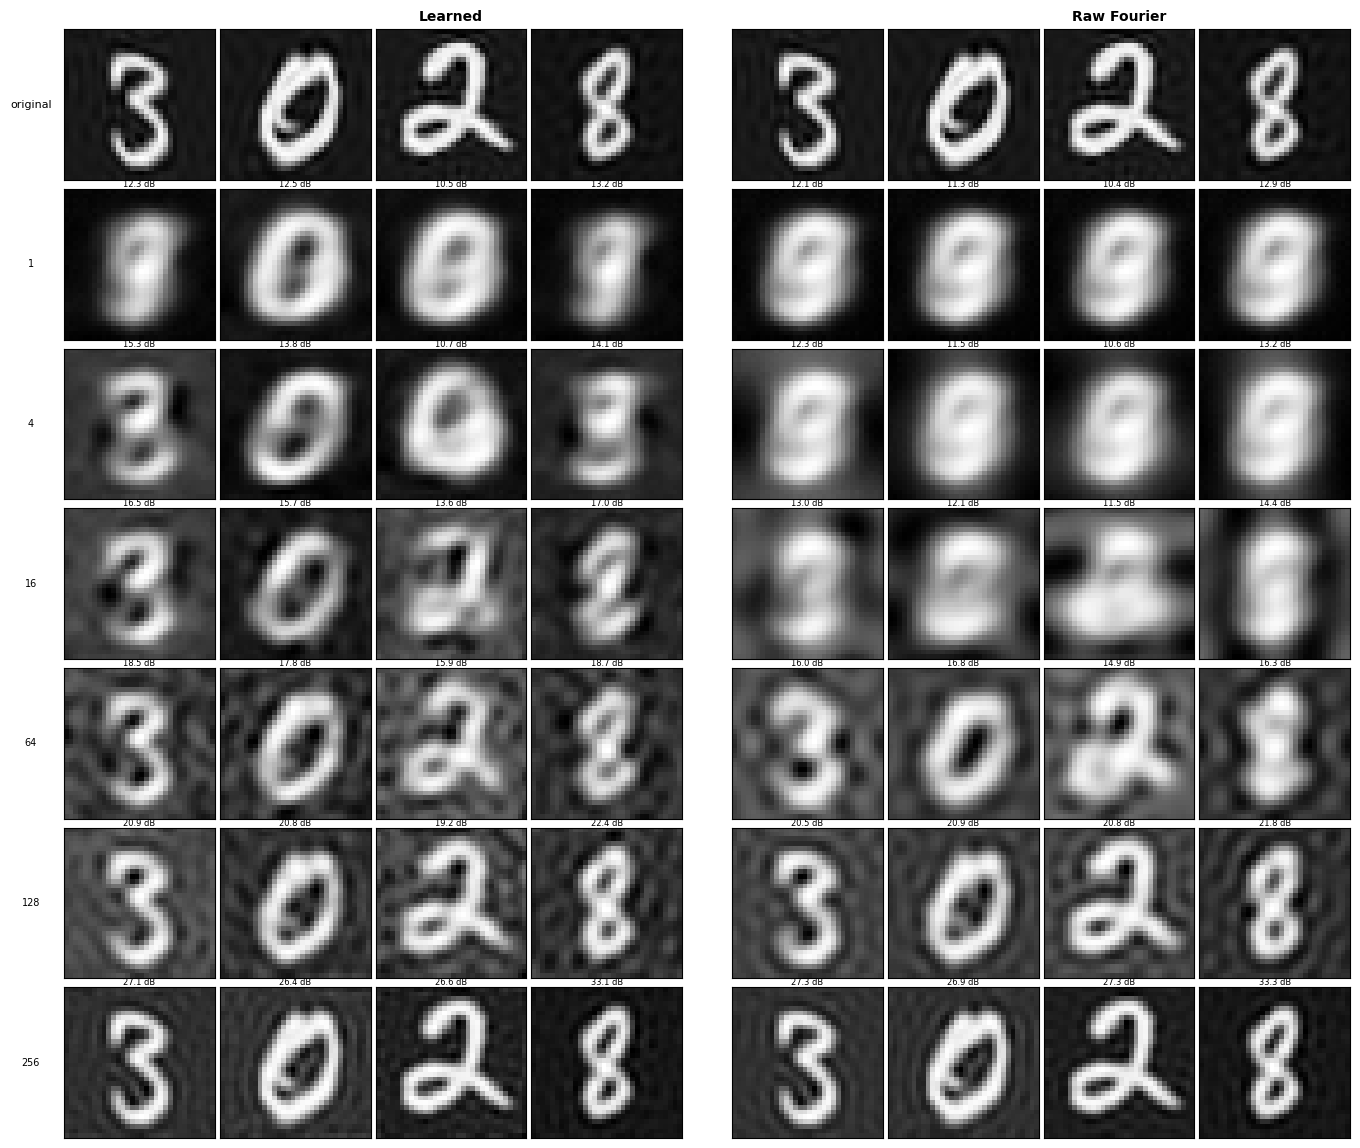

In [7]:

coords_recon = SquareSampler(stratified=True, add_noise=False).sample(N_RECON).to(device)
lad_recon    = torch.zeros(coords_recon.shape[0], device=device)

val_in = eval_inrs_at_coords(function_generator, coords_recon, N_VAL, 42, device)
print(f"In-distribution signals: {tuple(val_in.shape)}")

indices_recon, _ = top_probability_indices(initial_dictionary, max(RECON_ATOM_BUDGETS))
n_atoms_list = list(dict.fromkeys(min(budget, len(indices_recon)) for budget in RECON_ATOM_BUDGETS))
print(f"Reconstruction atom budgets: {n_atoms_list}")

identity_iso = IdentityIsometry().to(device).eval()
neural_isometry.shuffle_model_state(**model_state_kwargs)
neural_isometry.eval()

with torch.no_grad():
    initial_recons_in = [
        reconstruct_with_isometry(coords_recon, val_in, identity_iso, mean_function,
                                  initial_dictionary, indices_recon[:budget], synthesis=False, **pullback_kwargs).cpu()
        for budget in n_atoms_list
    ]
    learned_recons_in = [
        reconstruct_with_isometry(coords_recon, val_in, neural_isometry, mean_function,
                                  initial_dictionary, indices_recon[:budget], synthesis=True, **pullback_kwargs).cpu()
        for budget in n_atoms_list
    ]

metrics_in = plot_recon_grid(
    methods=[("Learned", learned_recons_in), (raw_basis_label, initial_recons_in)],
    val_imgs_cpu=val_in.cpu(),
    n_atoms_list=n_atoms_list,
    n=N_RECON,
    cmap=CMAP,
)

## 5  Reconstruction — Out-of-Distribution

The checkpoint configuration explicitly supplies `ood_function_generator` and `ood_label`. The notebook instantiates that configuration directly; `ood_fg` is reused by the spectral compactness section below.

In [8]:
ood_fg = instantiate(conf.ood_function_generator)
ood_label = str(conf.ood_label)
print(f"OOD: {ood_label}  n_inrs={ood_fg.n_inrs}")

OOD: MNIST test split  n_inrs=200


OOD signals: (4, 1024, 1)


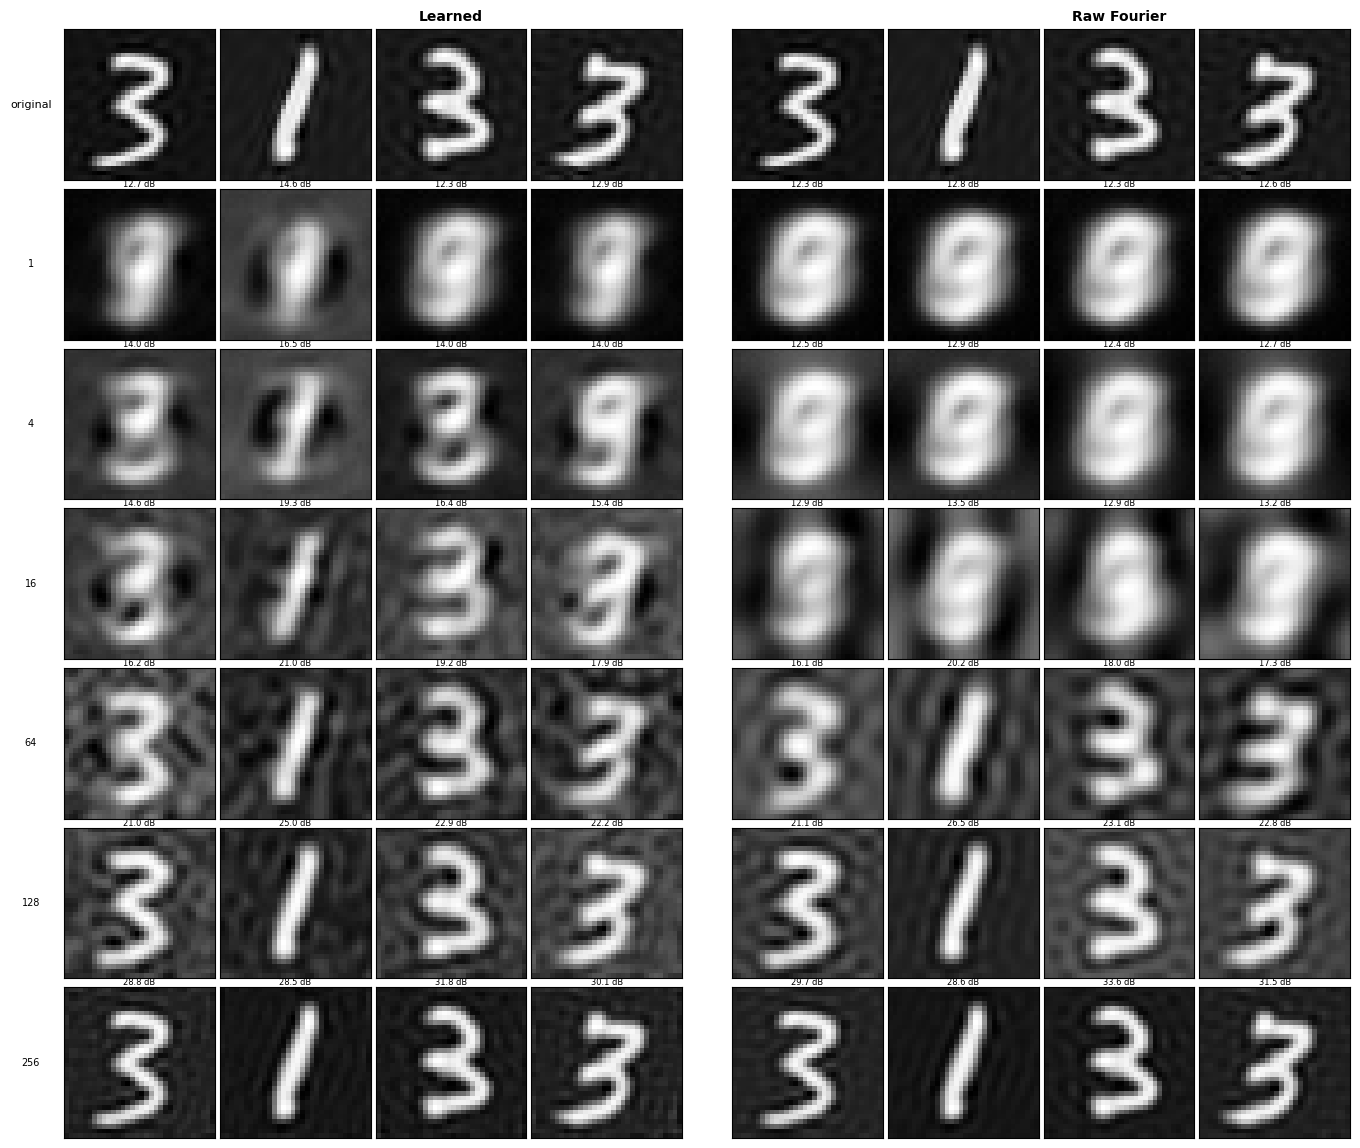

In [9]:
if ood_fg is not None:
    val_ood = eval_inrs_at_coords(ood_fg, coords_recon, N_VAL, 0, device)
    print(f"OOD signals: {tuple(val_ood.shape)}")

    neural_isometry.shuffle_model_state(**model_state_kwargs)
    neural_isometry.eval()

    with torch.no_grad():
        initial_recons_ood = [
            reconstruct_with_isometry(coords_recon, val_ood, identity_iso, mean_function,
                                      initial_dictionary, indices_recon[:budget], synthesis=False, **pullback_kwargs).cpu()
            for budget in n_atoms_list
        ]
        learned_recons_ood = [
            reconstruct_with_isometry(coords_recon, val_ood, neural_isometry, mean_function,
                                      initial_dictionary, indices_recon[:budget], synthesis=True, **pullback_kwargs).cpu()
            for budget in n_atoms_list
        ]

    metrics_ood = plot_recon_grid(
        methods=[("Learned", learned_recons_ood), (raw_basis_label, initial_recons_ood)],
        val_imgs_cpu=val_ood.cpu(),
        n_atoms_list=n_atoms_list,
        n=N_RECON,
        cmap=CMAP,
    )

## PSNR vs. Number of Atoms

Bar chart summarising reconstruction quality for every signal and truncation level, with one panel per signal. In-distribution (top) and OOD (bottom, if available).

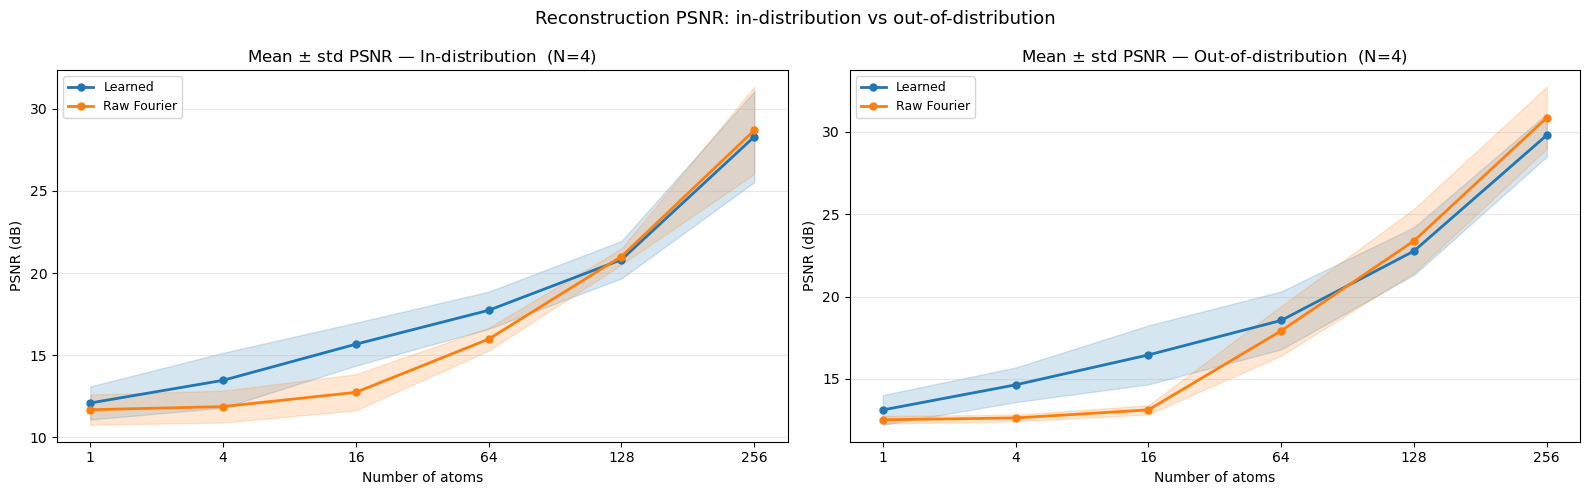

In [10]:
psnr_in_F = psnr_matrix(initial_recons_in, val_in.cpu())  # (N_VAL, K)
psnr_in_L = psnr_matrix(learned_recons_in, val_in.cpu())

in_methods = [("Learned", psnr_in_L), (raw_basis_label, psnr_in_F)]

if ood_fg is not None:
    psnr_ood_F = psnr_matrix(initial_recons_ood, val_ood.cpu())
    psnr_ood_L = psnr_matrix(learned_recons_ood, val_ood.cpu())
    ood_methods = [("Learned", psnr_ood_L), (raw_basis_label, psnr_ood_F)]
else:
    ood_methods = None

plot_psnr_line_chart(
    in_methods=in_methods,
    n_atoms_list=n_atoms_list,
    ood_methods=ood_methods,
)


## 6  Spectral Compactness — In-Distribution

For each of `N_SPEC` training-split SIRENs, compute the squared projection
coefficients

$$c_k^F = \langle f - \mu,\, \varphi_k\rangle, \qquad
  c_k^L = \langle Q^*(f - \mu),\, \varphi_k\rangle,$$

atoms ordered by $\nu(k)$ (prior PMF) descending.  If FPCA has converged,
the learned basis should pack more energy into the first few atoms.

In [11]:
coords_spec = SquareSampler(stratified=True, add_noise=False).sample(N_VIS_SPEC).to(device)
lad_spec    = torch.zeros(coords_spec.shape[0], device=device)

# Dictionary-neutral PMF prefix, capped for finite dictionaries.
spec_idx, spec_nu = top_probability_indices(initial_dictionary, SPECTRAL_ATOMS)
spec_idx = spec_idx.to(device)
spec_nu = spec_nu.cpu()
A_spec   = spec_idx.shape[0]
print(f"{A_spec} atoms  ν ∈ [{spec_nu[-1]:.2e}, {spec_nu[0]:.2e}]")

# Evaluate training SIRENs on the fixed grid
imgs_in = eval_inrs_at_coords(function_generator, coords_spec, N_SPEC, 0, device)
print(f"In-distribution signals: {tuple(imgs_in.shape)}")

256 atoms  ν ∈ [4.50e-05, 3.10e-01]
In-distribution signals: (200, 1024, 1)


In [12]:
neural_isometry.shuffle_model_state(**model_state_kwargs)
neural_isometry.eval()

with torch.no_grad():
    mu_spec = mean_function(coords_spec)                                     # (N, C)
    ctr_in  = imgs_in - mu_spec.unsqueeze(0)                                 # (n_in, N, C)

    atoms_tgt_spec = initial_dictionary.get_atoms(coords_spec, spec_idx, synthesis=False)  # raw baseline
    c_F_in  = pairwise_inner_product(atoms_tgt_spec, ctr_in, lad_spec)       # (A, n_in)

    src_c_in, src_l_in, pulled_in = neural_isometry.pullback(
        tgt_coords=coords_spec, tgt_logabsdet=lad_spec, tgt_field=ctr_in,
        **pullback_kwargs,
    )
    atoms_src_spec = initial_dictionary.get_atoms(src_c_in, spec_idx, synthesis=True)     # (A, N_src, C)
    c_L_in  = pairwise_inner_product(atoms_src_spec, pulled_in, src_l_in)    # (A, n_in)

sq_F_in = c_F_in.pow(2).cpu()   # (A, n_in)
sq_L_in = c_L_in.pow(2).cpu()
e_F_in  = sq_F_in.mean(-1)      # (A,) mean squared coeff per atom
e_L_in  = sq_L_in.mean(-1)
print(f"Total energy (in-dist) — {dictionary_name}: {e_F_in.sum():.4f}  Learned: {e_L_in.sum():.4f}")

Total energy (in-dist) — Fourier: 0.0677  Learned: 0.0675


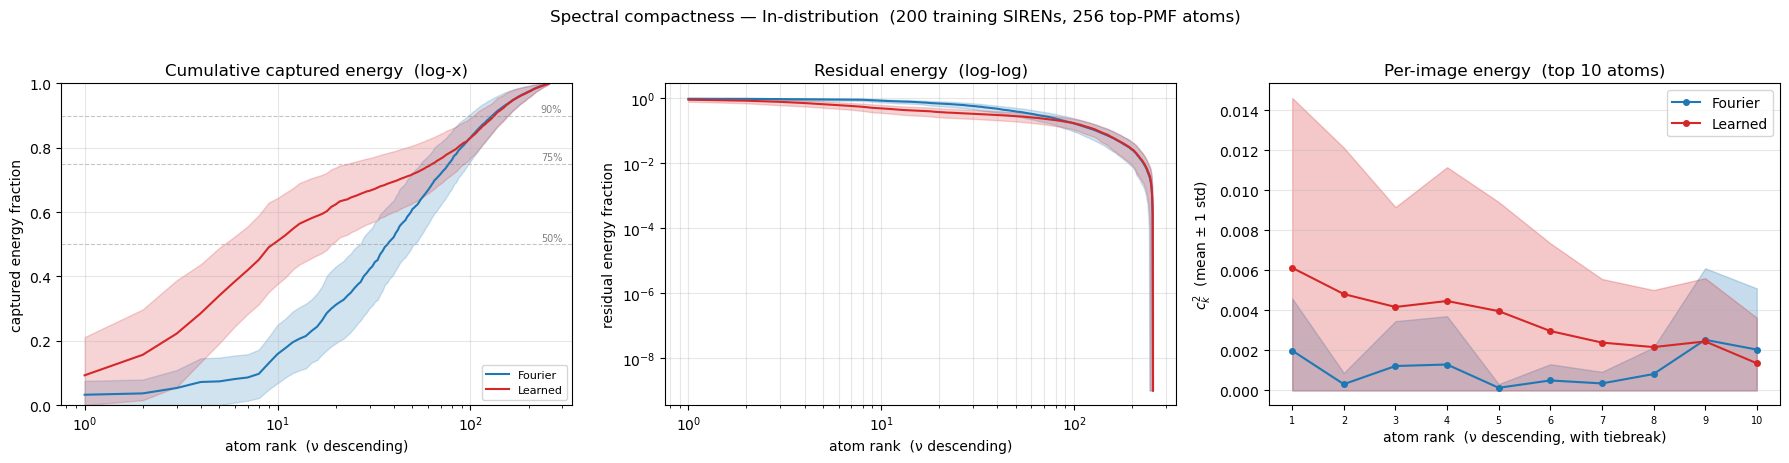


 Threshold     Fourier     Learned      gain
       50%         38         10    +73.7%
       75%         78         64    +17.9%
       90%        131        134     -2.3%


In [13]:
# Per-image cumulative fraction of total energy: (A, n_in)
cum_F_in_per_img = sq_F_in.cumsum(0) / (sq_F_in.sum(0, keepdim=True) + 1e-15)
cum_L_in_per_img = sq_L_in.cumsum(0) / (sq_L_in.sum(0, keepdim=True) + 1e-15)

cum_F_in_mean = cum_F_in_per_img.mean(dim=1).numpy()
cum_F_in_std  = cum_F_in_per_img.std(dim=1).numpy()
cum_L_in_mean = cum_L_in_per_img.mean(dim=1).numpy()
cum_L_in_std  = cum_L_in_per_img.std(dim=1).numpy()

x_in = np.arange(1, A_spec + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

plot_spectral_compactness(
    [
        dict(label=dictionary_name, xs=x_in, mean=cum_F_in_mean, std=cum_F_in_std, color='C0'),
        dict(label="Learned", xs=x_in, mean=cum_L_in_mean, std=cum_L_in_std, color='C3'),
    ],
    xlabel="atom rank  (ν descending)",
    xscale="log",
    axes=(axes[0], axes[1]),
)

# ── Per-atom mean ± std  (top N_VIOLIN atoms) ─────────────────────────────
ax  = axes[2]
nv  = min(N_VIOLIN, A_spec)
pos = np.arange(1, nv + 1)

mean_F_in = sq_F_in[:nv].mean(dim=-1).numpy()
std_F_in  = sq_F_in[:nv].std(dim=-1).numpy()
mean_L_in = sq_L_in[:nv].mean(dim=-1).numpy()
std_L_in  = sq_L_in[:nv].std(dim=-1).numpy()

ax.plot(pos, mean_F_in, 'o-', lw=1.5, ms=4, color='C0', label=dictionary_name)
ax.fill_between(pos, np.maximum(mean_F_in - std_F_in, 0), mean_F_in + std_F_in,
                alpha=0.25, color='C0')
ax.plot(pos, mean_L_in, 'o-', lw=1.5, ms=4, color='C3', label="Learned")
ax.fill_between(pos, np.maximum(mean_L_in - std_L_in, 0), mean_L_in + std_L_in,
                alpha=0.25, color='C3')
ax.set_xticks(pos)
ax.set_xticklabels([str(k) for k in pos], fontsize=7)
ax.set_xlabel("atom rank  (ν descending, with tiebreak)")
ax.set_ylabel("$c_k^2$  (mean ± 1 std)")
ax.set_title(f"Per-image energy  (top {nv} atoms)")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    f"Spectral compactness — In-distribution  "
    f"({imgs_in.shape[0]} training SIRENs, {A_spec} top-PMF atoms)",
    y=1.02,
)
plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────────
print(f"\n{'Threshold':>10}  {dictionary_name:>10}  {'Learned':>10}  {'gain':>8}")
for frac in [0.50, 0.75, 0.90]:
    nf = int((cum_F_in_mean < frac).sum()) + 1
    nl = int((cum_L_in_mean < frac).sum()) + 1
    gain = (nf - nl) / max(nf, 1) * 100
    print(f"{frac*100:>9.0f}%  {nf:>9d}  {nl:>9d}  {gain:>+7.1f}%")


## 7  Spectral Compactness — Out-of-Distribution

Load held-out SIRENs and repeat the spectral analysis:

| Training dataset | OOD source |
|---|---|
| `ImplicitZooMNISTDataset` | `mnist_png_testing*` (MNIST test split) |
| `ImplicitZooCIFARDataset` | `split='eval'` (10 000 held-out CIFAR-10 SIRENs) |

A well-trained FPCA basis should generalise: the learned representation should
remain compact on held-out data from the same distribution.

OOD signals for spectral: (200, 1024, 1)
Total energy (OOD) — Fourier: 0.0663  Learned: 0.0660


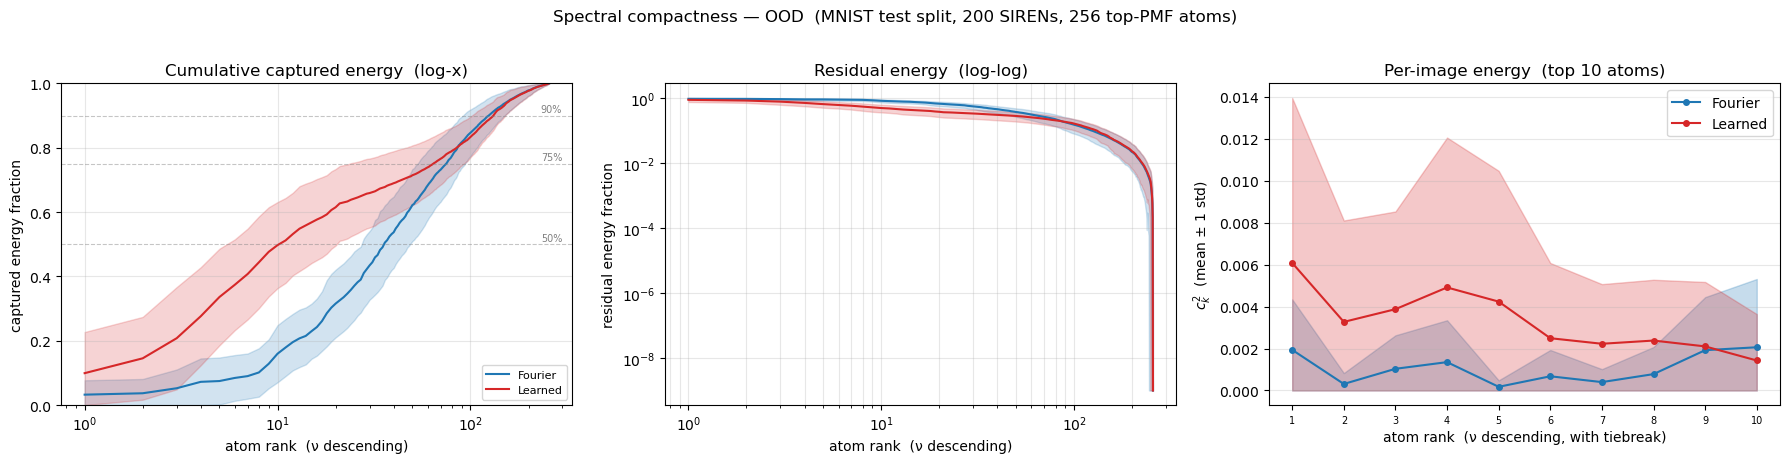


 Threshold     Fourier     Learned      gain
       50%         36         11    +69.4%
       75%         75         65    +13.3%
       90%        125        132     -5.6%


In [14]:
if ood_fg is not None:
    imgs_ood = eval_inrs_at_coords(ood_fg, coords_spec, N_SPEC, 0, device)
    print(f"OOD signals for spectral: {tuple(imgs_ood.shape)}")
    neural_isometry.shuffle_model_state(**model_state_kwargs)
    neural_isometry.eval()

    with torch.no_grad():
        ctr_ood = imgs_ood - mu_spec.unsqueeze(0)                                # (n_ood, N, C)

        c_F_ood = pairwise_inner_product(atoms_tgt_spec, ctr_ood, lad_spec)      # (A, n_ood)

        src_c_o, src_l_o, pulled_ood = neural_isometry.pullback(
            tgt_coords=coords_spec, tgt_logabsdet=lad_spec, tgt_field=ctr_ood,
            **pullback_kwargs,
        )
        atoms_src_ood = initial_dictionary.get_atoms(src_c_o, spec_idx, synthesis=True)  # (A, N_src, C)
        c_L_ood = pairwise_inner_product(atoms_src_ood, pulled_ood, src_l_o)     # (A, n_ood)

    sq_F_ood = c_F_ood.pow(2).cpu()
    sq_L_ood = c_L_ood.pow(2).cpu()
    e_F_ood  = sq_F_ood.mean(-1)
    e_L_ood  = sq_L_ood.mean(-1)
    print(f"Total energy (OOD) — {dictionary_name}: {e_F_ood.sum():.4f}  Learned: {e_L_ood.sum():.4f}")

    # Per-image cumulative fraction of total energy: (A, n_ood)
    cum_F_ood_per_img = sq_F_ood.cumsum(0) / (sq_F_ood.sum(0, keepdim=True) + 1e-15)
    cum_L_ood_per_img = sq_L_ood.cumsum(0) / (sq_L_ood.sum(0, keepdim=True) + 1e-15)

    cum_F_ood_mean = cum_F_ood_per_img.mean(dim=1).numpy()
    cum_F_ood_std  = cum_F_ood_per_img.std(dim=1).numpy()
    cum_L_ood_mean = cum_L_ood_per_img.mean(dim=1).numpy()
    cum_L_ood_std  = cum_L_ood_per_img.std(dim=1).numpy()

    x_ood = np.arange(1, A_spec + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    plot_spectral_compactness(
        [
            dict(label=dictionary_name, xs=x_ood, mean=cum_F_ood_mean, std=cum_F_ood_std, color='C0'),
            dict(label="Learned", xs=x_ood, mean=cum_L_ood_mean, std=cum_L_ood_std, color='C3'),
        ],
        xlabel="atom rank  (ν descending)",
        xscale="log",
        axes=(axes[0], axes[1]),
    )

    # ── Per-atom mean ± std  (top N_VIOLIN atoms) ─────────────────────────
    ax  = axes[2]
    nv  = min(N_VIOLIN, A_spec)
    pos = np.arange(1, nv + 1)

    mean_F_ood = sq_F_ood[:nv].mean(dim=-1).numpy()
    std_F_ood  = sq_F_ood[:nv].std(dim=-1).numpy()
    mean_L_ood = sq_L_ood[:nv].mean(dim=-1).numpy()
    std_L_ood  = sq_L_ood[:nv].std(dim=-1).numpy()

    ax.plot(pos, mean_F_ood, 'o-', lw=1.5, ms=4, color='C0', label=dictionary_name)
    ax.fill_between(pos, np.maximum(mean_F_ood - std_F_ood, 0), mean_F_ood + std_F_ood,
                    alpha=0.25, color='C0')
    ax.plot(pos, mean_L_ood, 'o-', lw=1.5, ms=4, color='C3', label="Learned")
    ax.fill_between(pos, np.maximum(mean_L_ood - std_L_ood, 0), mean_L_ood + std_L_ood,
                    alpha=0.25, color='C3')
    ax.set_xticks(pos)
    ax.set_xticklabels([str(k) for k in pos], fontsize=7)
    ax.set_xlabel("atom rank  (ν descending, with tiebreak)")
    ax.set_ylabel("$c_k^2$  (mean ± 1 std)")
    ax.set_title(f"Per-image energy  (top {nv} atoms)")
    ax.legend(); ax.grid(True, alpha=0.3, axis="y")

    plt.suptitle(
        f"Spectral compactness — OOD  "
        f"({ood_label}, {imgs_ood.shape[0]} SIRENs, {A_spec} top-PMF atoms)",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    # ── Summary table ──────────────────────────────────────────────────────────
    print(f"\n{'Threshold':>10}  {dictionary_name:>10}  {'Learned':>10}  {'gain':>8}")
    for frac in [0.50, 0.75, 0.90]:
        nf = int((cum_F_ood_mean < frac).sum()) + 1
        nl = int((cum_L_ood_mean < frac).sum()) + 1
        gain = (nf - nl) / max(nf, 1) * 100
        print(f"{frac*100:>9.0f}%  {nf:>9d}  {nl:>9d}  {gain:>+7.1f}%")